In [2]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

PKLs = []
PKL_titles = []
for file in os.listdir("./"):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

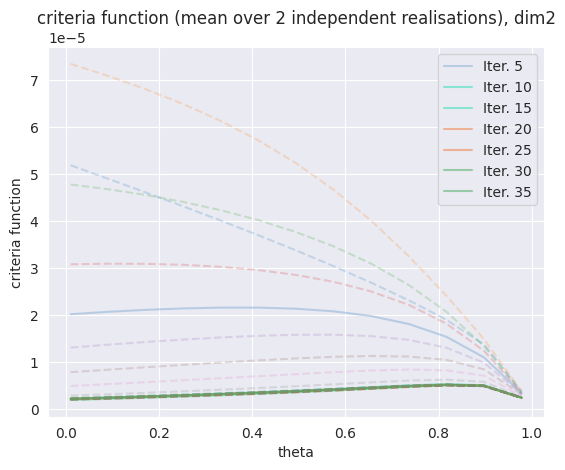

In [3]:
GRID_ESJD = jnp.linspace(0.01, 8, 100)

NUM_COLORS = 30
color_set = set()
while len(color_set)<NUM_COLORS:
    random_integers = [np.random.randint(0, 255)/255 for _ in range(3)]
    color_set.add(tuple(random_integers))


color_set = list(color_set)
color_set = [tuple(n) for n in color_set]
idx = 1
mpm1 = PKLs[idx]['res'][0].shape[2]*(PKLs[idx]['res'][0].shape[3]-1)
for j in range(1, PKLs[idx]['res'][5].shape[1]):
    if j % 5 ==0:
        plt.plot(GRID_ESJD, PKLs[idx]['res'][5].mean(axis=0)[j,:]/mpm1, label=f"Iter. {str(j)}", alpha=0.5, color=color_set[j//10], linestyle="solid")
    else:
        plt.plot(GRID_ESJD, PKLs[idx]['res'][5].mean(axis=0)[j,:]/mpm1, alpha=0.2, linestyle="--")
plt.legend()
plt.title(f"criteria function (mean over {PKLs[idx]['res'][5].shape[0]} independent realisations), dim{PKLs[idx]['res'][0].shape[-1]}")
plt.ylabel("criteria function")
plt.xlabel("theta")
plt.savefig(f"{PKL_titles[idx]}criteria_function.png")
